# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [3]:
df = pd.read_csv("C:\\Users\\hp\\OneDrive\\ドキュメント\\OIBSIP\\Task 2 - Unemployment Analysis with Python\\Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Understand the Data

In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [5]:
# Check missing values:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

# Data Cleaning

In [6]:
# If dataset has missing values:
df = df.dropna()

In [9]:
# If there's a date column:
df.columns = df.columns.str.strip()   # remove spaces
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Basic Analysis

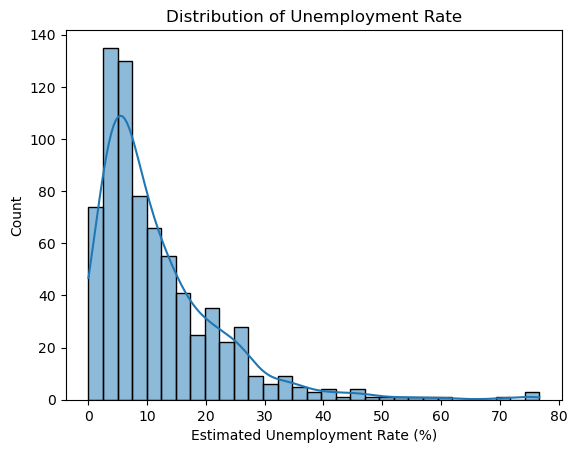

In [10]:
#Unemployment rate distribution
plt.figure()
sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

# Time Series Analysis (COVID Impact)

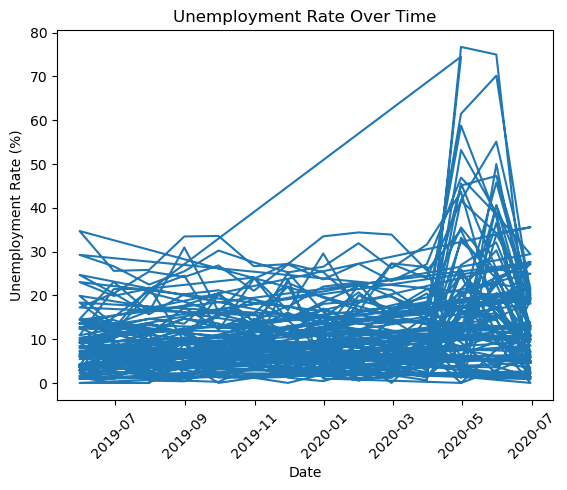

In [11]:
plt.figure()
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Compare Before vs During COVID

In [12]:
# Create a new column
df['Year'] = df['Date'].dt.year

before_covid = df[df['Year'] < 2020]
during_covid = df[df['Year'] >= 2020]

print("Before COVID Mean:", before_covid['Estimated Unemployment Rate (%)'].mean())
print("During COVID Mean:", during_covid['Estimated Unemployment Rate (%)'].mean())

Before COVID Mean: 9.399046511627906
During COVID Mean: 15.10158064516129


# State-wise Analysis (if dataset has states)

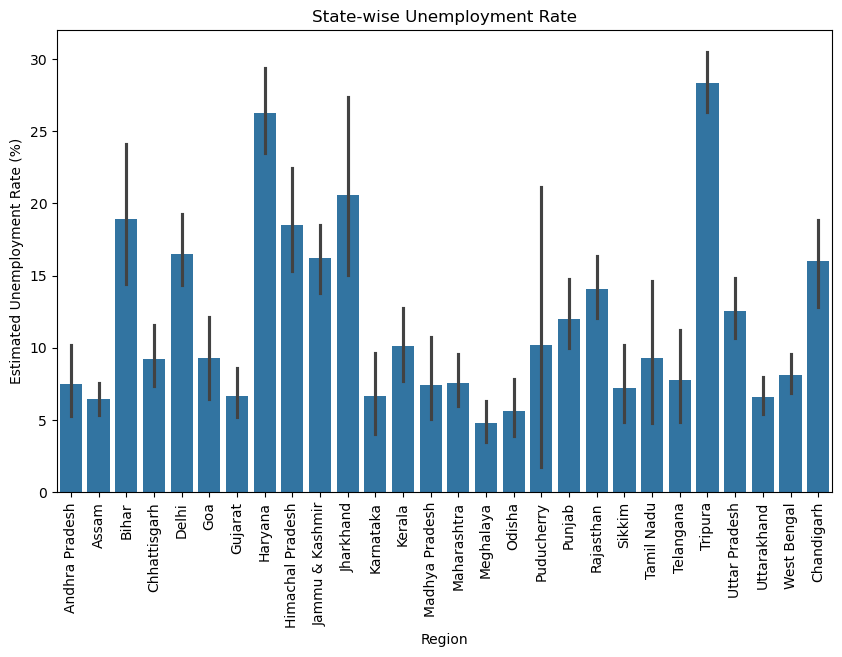

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title("State-wise Unemployment Rate")
plt.show()

# Heatmap (Correlation)

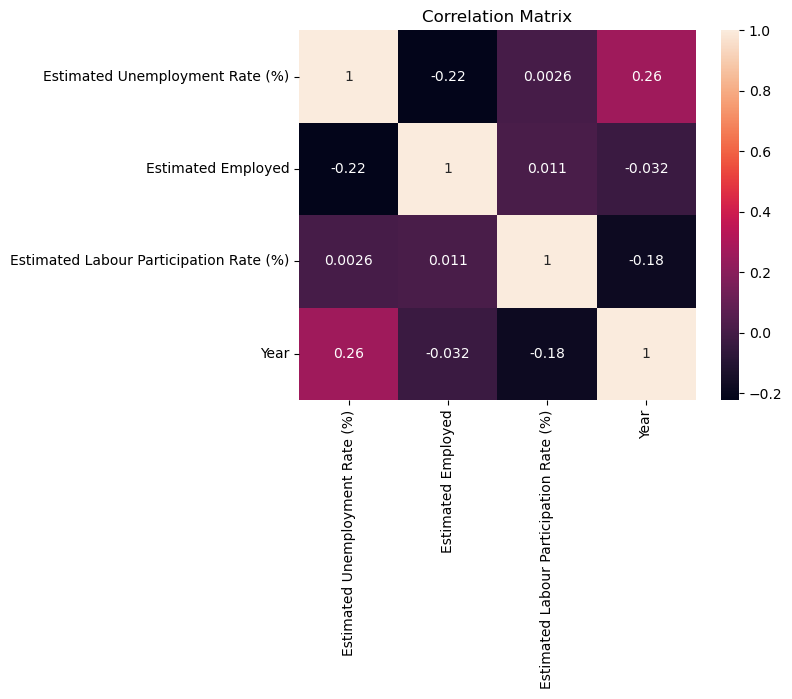

In [17]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

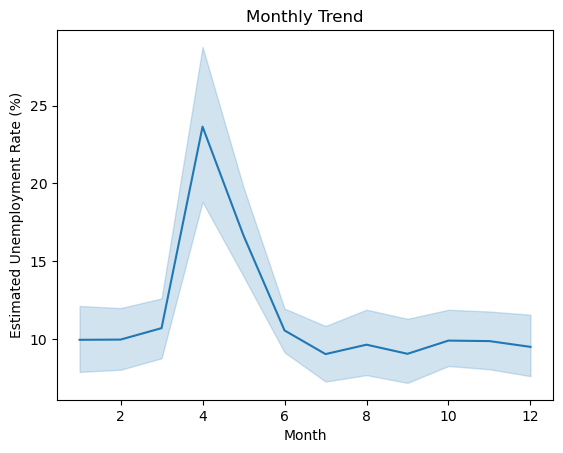

In [18]:
# Monthly trend
df['Month'] = df['Date'].dt.month

sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Monthly Trend")
plt.show()